# Лабораторная работа №4 (Лабораторная работа №1)
# Необходимые и достаточные условия существования условного экстремума

**ФИО:** Сеньков Денис Владимирович  
**Группа:** ИУ5-24М  
**Вариант:** 7 (задание 1.7)

## Цель работы

1. Исследование необходимых и достаточных условий существования экстремума функции с учётом ограничений (условный экстремум).
2. Вычисление экстремумов функции.

## Постановка задачи (Вариант 1.7)

Найти экстремум функции:

$$f(x) = (x_1^2 + 3)^2 - (x_2^2 + 2)^2 - 10 \to extr$$

при ограничениях:
- $g_1(x) = x_1^2 + x_2^2 - 1 \le 0$
- $g_2(x) = -x_1 \le 0$
- $g_3(x) = -x_2 \le 0$

То есть ищем экстремум на множестве $X = \{x : x_1^2 + x_2^2 \le 1, \; x_1 \ge 0, \; x_2 \ge 0 \}$ (первая четверть единичного круга).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from scipy.optimize import minimize
import sympy as sp

plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

## Визуализация задачи

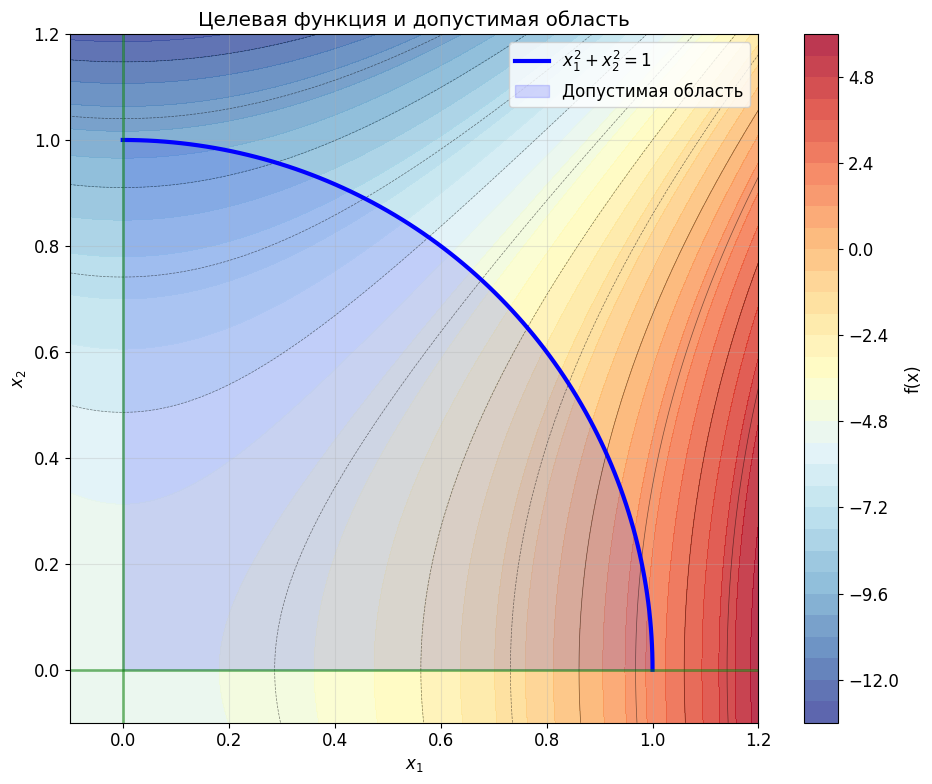

In [2]:
def f(x1, x2):
    return (x1**2 + 3)**2 - (x2**2 + 2)**2 - 10

x1_range = np.linspace(-0.1, 1.2, 300)
x2_range = np.linspace(-0.1, 1.2, 300)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f(X1, X2)

fig, ax = plt.subplots(figsize=(10, 8))

cs = ax.contourf(X1, X2, Z, levels=30, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(cs, ax=ax, label='f(x)')
ax.contour(X1, X2, Z, levels=15, colors='black', linewidths=0.5, alpha=0.5)

theta = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(theta), np.sin(theta), 'b-', linewidth=3, label='$x_1^2+x_2^2=1$')
ax.fill_between(np.cos(theta), 0, np.sin(theta), alpha=0.15, color='blue', label='Допустимая область')

ax.axhline(y=0, color='green', linewidth=2, alpha=0.5)
ax.axvline(x=0, color='green', linewidth=2, alpha=0.5)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Целевая функция и допустимая область')
ax.legend(loc='upper right')
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.1, 1.2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Шаг 1. Составление обобщённой функции Лагранжа

$$L(x, \lambda_0, \lambda) = \lambda_0 f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x) + \lambda_3 g_3(x)$$

$$L = \lambda_0 \left[(x_1^2+3)^2 - (x_2^2+2)^2 - 10\right] + \lambda_1(x_1^2+x_2^2-1) + \lambda_2(-x_1) + \lambda_3(-x_2)$$

In [3]:
x1, x2 = sp.symbols('x1 x2', real=True)
l0, l1, l2, l3 = sp.symbols('lambda_0 lambda_1 lambda_2 lambda_3')

f_sym = (x1**2 + 3)**2 - (x2**2 + 2)**2 - 10
g1_sym = x1**2 + x2**2 - 1
g2_sym = -x1
g3_sym = -x2

L_gen = l0 * f_sym + l1 * g1_sym + l2 * g2_sym + l3 * g3_sym
L_class = f_sym + l1 * g1_sym + l2 * g2_sym + l3 * g3_sym

print('Обобщённая функция Лагранжа:')
sp.pprint(sp.expand(L_gen))
print('\nКлассическая функция Лагранжа (λ₀=1):')
sp.pprint(sp.expand(L_class))

Обобщённая функция Лагранжа:
     4          2        4          2               2        2                 ↪
λ₀⋅x₁  + 6⋅λ₀⋅x₁  - λ₀⋅x₂  - 4⋅λ₀⋅x₂  - 5⋅λ₀ + λ₁⋅x₁  + λ₁⋅x₂  - λ₁ - λ₂⋅x₁ -  ↪

↪      
↪ λ₃⋅x₂

Классическая функция Лагранжа (λ₀=1):
     2        2                          4       2     4       2    
λ₁⋅x₁  + λ₁⋅x₂  - λ₁ - λ₂⋅x₁ - λ₃⋅x₂ + x₁  + 6⋅x₁  - x₂  - 4⋅x₂  - 5


## Шаг 2. Необходимые условия экстремума первого порядка

Рассматриваем регулярный случай $\lambda_0 \neq 0$, полагаем $\lambda_0 = 1$.

**Система уравнений:**

А) Условие стационарности:
$$\frac{\partial L}{\partial x_1} = 0, \quad \frac{\partial L}{\partial x_2} = 0$$

Б) Условие допустимости:
$$g_1(x) \le 0, \quad g_2(x) \le 0, \quad g_3(x) \le 0$$

В) Неотрицательность множителей (для минимума): $\lambda_j \ge 0$;  
   Неположительность (для максимума): $\lambda_j \le 0$.

Г) Условие дополняющей нежёсткости:
$$\lambda_1 g_1(x) = 0, \quad \lambda_2 g_2(x) = 0, \quad \lambda_3 g_3(x) = 0$$

In [4]:
dL_dx1 = sp.diff(L_class, x1)
dL_dx2 = sp.diff(L_class, x2)

print('∂L/∂x₁ =')
sp.pprint(sp.simplify(dL_dx1))
print('\n∂L/∂x₂ =')
sp.pprint(sp.simplify(dL_dx2))

∂L/∂x₁ =
                    ⎛  2    ⎞
2⋅λ₁⋅x₁ - λ₂ + 4⋅x₁⋅⎝x₁  + 3⎠

∂L/∂x₂ =
                    ⎛  2    ⎞
2⋅λ₁⋅x₂ - λ₃ - 4⋅x₂⋅⎝x₂  + 2⎠


## Шаг 3. Решение системы ККТ (перебор случаев активности ограничений)

По условию дополняющей нежёсткости, для каждого ограничения-неравенства либо $\lambda_j = 0$, либо $g_j(x^*) = 0$. Перебираем все комбинации активных ограничений.

In [5]:
from itertools import product

stationary_points = []

cases = list(product([True, False], repeat=3))

for case_idx, (g1_active, g2_active, g3_active) in enumerate(cases):
    eqs = [dL_dx1, dL_dx2]
    unknowns = [x1, x2, l1, l2, l3]

    if g1_active:
        eqs.append(g1_sym)
    else:
        eqs.append(l1)

    if g2_active:
        eqs.append(g2_sym)
    else:
        eqs.append(l2)

    if g3_active:
        eqs.append(g3_sym)
    else:
        eqs.append(l3)

    try:
        solutions = sp.solve(eqs, unknowns, dict=True)
    except:
        solutions = []

    active_str = []
    if g1_active: active_str.append('g1')
    if g2_active: active_str.append('g2')
    if g3_active: active_str.append('g3')
    active_label = ', '.join(active_str) if active_str else 'нет активных'

    for sol in solutions:
        x1_val = float(sol.get(x1, 0))
        x2_val = float(sol.get(x2, 0))
        l1_val = float(sol.get(l1, 0))
        l2_val = float(sol.get(l2, 0))
        l3_val = float(sol.get(l3, 0))

        # Проверка допустимости
        g1_v = x1_val**2 + x2_val**2 - 1
        g2_v = -x1_val
        g3_v = -x2_val

        feasible = (g1_v <= 1e-8 and g2_v <= 1e-8 and g3_v <= 1e-8)

        f_val = float(f_sym.subs([(x1, x1_val), (x2, x2_val)]))

        stationary_points.append({
            'case': active_label,
            'x1': x1_val, 'x2': x2_val,
            'l1': l1_val, 'l2': l2_val, 'l3': l3_val,
            'f': f_val,
            'feasible': feasible,
            'g1_active': g1_active, 'g2_active': g2_active, 'g3_active': g3_active,
        })

print(f'Найдено стационарных точек: {len(stationary_points)}')
print(f'Из них допустимых: {sum(1 for p in stationary_points if p["feasible"])}')

Найдено стационарных точек: 12
Из них допустимых: 8


In [6]:
print('Допустимые стационарные точки ККТ:')
print('=' * 90)

feasible_points = [p for p in stationary_points if p['feasible']]

for i, p in enumerate(feasible_points):
    print(f'\nТочка {i+1}: активные ограничения: [{p["case"]}]')
    print(f'  x* = ({p["x1"]:.6f}, {p["x2"]:.6f})')
    print(f'  f(x*) = {p["f"]:.6f}')
    print(f'  λ₁ = {p["l1"]:.6f}, λ₂ = {p["l2"]:.6f}, λ₃ = {p["l3"]:.6f}')

    g1_v = p['x1']**2 + p['x2']**2 - 1
    g2_v = -p['x1']
    g3_v = -p['x2']
    print(f'  g1 = {g1_v:.6f}, g2 = {g2_v:.6f}, g3 = {g3_v:.6f}')

Допустимые стационарные точки ККТ:

Точка 1: активные ограничения: [g1, g2]
  x* = (0.000000, 1.000000)
  f(x*) = -10.000000
  λ₁ = 6.000000, λ₂ = 0.000000, λ₃ = 0.000000
  g1 = 0.000000, g2 = -0.000000, g3 = -1.000000

Точка 2: активные ограничения: [g1, g3]
  x* = (1.000000, 0.000000)
  f(x*) = 2.000000
  λ₁ = -8.000000, λ₂ = 0.000000, λ₃ = 0.000000
  g1 = 0.000000, g2 = -1.000000, g3 = -0.000000

Точка 3: активные ограничения: [g1]
  x* = (1.000000, 0.000000)
  f(x*) = 2.000000
  λ₁ = -8.000000, λ₂ = 0.000000, λ₃ = 0.000000
  g1 = 0.000000, g2 = -1.000000, g3 = -0.000000

Точка 4: активные ограничения: [g1]
  x* = (0.000000, 1.000000)
  f(x*) = -10.000000
  λ₁ = 6.000000, λ₂ = 0.000000, λ₃ = 0.000000
  g1 = 0.000000, g2 = -0.000000, g3 = -1.000000

Точка 5: активные ограничения: [g2, g3]
  x* = (0.000000, 0.000000)
  f(x*) = -5.000000
  λ₁ = 0.000000, λ₂ = 0.000000, λ₃ = 0.000000
  g1 = -1.000000, g2 = -0.000000, g3 = -0.000000

Точка 6: активные ограничения: [g2]
  x* = (0.000000, 

## Шаг 4. Проверка достаточных условий экстремума

### Способ 1: Анализ второго дифференциала функции Лагранжа

Записываем матрицу Гессе функции Лагранжа и проверяем знакоопределённость на допустимых направлениях.

In [7]:
H_L = sp.Matrix([
    [sp.diff(L_class, x1, x1), sp.diff(L_class, x1, x2)],
    [sp.diff(L_class, x2, x1), sp.diff(L_class, x2, x2)]
])

print('Матрица Гессе классической функции Лагранжа:')
sp.pprint(sp.simplify(H_L))

Матрица Гессе классической функции Лагранжа:
⎡            2                        ⎤
⎢2⋅λ₁ + 12⋅x₁  + 12          0        ⎥
⎢                                     ⎥
⎢                                2    ⎥
⎣        0           2⋅λ₁ - 12⋅x₂  - 8⎦


In [8]:
print('Проверка достаточных условий в каждой стационарной точке:')
print('=' * 80)

for i, p in enumerate(feasible_points):
    subs = {x1: p['x1'], x2: p['x2'], l1: p['l1'], l2: p['l2'], l3: p['l3']}
    H_val = H_L.subs(subs)
    H_np = np.array(H_val.tolist(), dtype=float)
    eigenvalues = np.linalg.eigvalsh(H_np)

    print(f'\nТочка {i+1}: x* = ({p["x1"]:.4f}, {p["x2"]:.4f}), f = {p["f"]:.4f}')
    print(f'  Активные: [{p["case"]}]')
    print(f'  Матрица Гессе L:\n  {H_np}')
    print(f'  Собственные числа: {eigenvalues}')

    # Число активных ограничений
    l_count = sum([p['g1_active'], p['g2_active'], p['g3_active']])
    n_vars = 2

    if l_count >= n_vars:
        # Достаточные условия 1-го порядка
        all_pos = all(v > 0 for k, v in [('l1', p['l1']), ('l2', p['l2']), ('l3', p['l3'])]
                      if p[f'g{int(k[1])}_active'])
        all_neg = all(v < 0 for k, v in [('l1', p['l1']), ('l2', p['l2']), ('l3', p['l3'])]
                      if p[f'g{int(k[1])}_active'])
        if all_pos:
            print(f'  l >= n, все λ_j > 0 для активных => ЛОКАЛЬНЫЙ МИНИМУМ')
        elif all_neg:
            print(f'  l >= n, все λ_j < 0 для активных => ЛОКАЛЬНЫЙ МАКСИМУМ')
        else:
            print(f'  l >= n, но множители разных знаков — проверяем 2-й порядок')
    else:
        if all(ev > 0 for ev in eigenvalues):
            print(f'  Гессиан положительно определён => ЛОКАЛЬНЫЙ МИНИМУМ')
        elif all(ev < 0 for ev in eigenvalues):
            print(f'  Гессиан отрицательно определён => ЛОКАЛЬНЫЙ МАКСИМУМ')
        else:
            # Проверяем на подпространстве касательных направлений
            print(f'  Гессиан знаконеопределён — требуется анализ на подпространстве')

Проверка достаточных условий в каждой стационарной точке:

Точка 1: x* = (0.0000, 1.0000), f = -10.0000
  Активные: [g1, g2]
  Матрица Гессе L:
  [[24.  0.]
 [ 0. -8.]]
  Собственные числа: [-8. 24.]
  l >= n, но множители разных знаков — проверяем 2-й порядок

Точка 2: x* = (1.0000, 0.0000), f = 2.0000
  Активные: [g1, g3]
  Матрица Гессе L:
  [[  8.   0.]
 [  0. -24.]]
  Собственные числа: [-24.   8.]
  l >= n, но множители разных знаков — проверяем 2-й порядок

Точка 3: x* = (1.0000, 0.0000), f = 2.0000
  Активные: [g1]
  Матрица Гессе L:
  [[  8.   0.]
 [  0. -24.]]
  Собственные числа: [-24.   8.]
  Гессиан знаконеопределён — требуется анализ на подпространстве

Точка 4: x* = (0.0000, 1.0000), f = -10.0000
  Активные: [g1]
  Матрица Гессе L:
  [[24.  0.]
 [ 0. -8.]]
  Собственные числа: [-8. 24.]
  Гессиан знаконеопределён — требуется анализ на подпространстве

Точка 5: x* = (0.0000, 0.0000), f = -5.0000
  Активные: [g2, g3]
  Матрица Гессе L:
  [[12.  0.]
 [ 0. -8.]]
  Собственны

### Способ 2: Численная проверка с помощью scipy.optimize

In [9]:
def f_np(x):
    return (x[0]**2 + 3)**2 - (x[1]**2 + 2)**2 - 10

constraints = [
    {'type': 'ineq', 'fun': lambda x: 1 - x[0]**2 - x[1]**2},  # g1 <= 0 => 1-g1 >= 0
    {'type': 'ineq', 'fun': lambda x: x[0]},                     # x1 >= 0
    {'type': 'ineq', 'fun': lambda x: x[1]},                     # x2 >= 0
]

print('Поиск МИНИМУМА (scipy SLSQP):')
print('-' * 50)
for x0 in [[0.5, 0.5], [0.1, 0.9], [0.9, 0.1], [0.01, 0.01]]:
    res_min = minimize(f_np, x0, method='SLSQP', constraints=constraints)
    if res_min.success:
        print(f'  x0={x0} => x*=({res_min.x[0]:.6f}, {res_min.x[1]:.6f}), f={res_min.fun:.6f}')

print(f'\nПоиск МАКСИМУМА (минимизация -f):')
print('-' * 50)
for x0 in [[0.5, 0.5], [0.1, 0.9], [0.9, 0.1], [0.01, 0.01]]:
    res_max = minimize(lambda x: -f_np(x), x0, method='SLSQP', constraints=constraints)
    if res_max.success:
        print(f'  x0={x0} => x*=({res_max.x[0]:.6f}, {res_max.x[1]:.6f}), f={-res_max.fun:.6f}')

Поиск МИНИМУМА (scipy SLSQP):
--------------------------------------------------
  x0=[0.5, 0.5] => x*=(0.000000, 1.000000), f=-10.000000
  x0=[0.1, 0.9] => x*=(-0.000000, 1.000000), f=-10.000000
  x0=[0.9, 0.1] => x*=(0.000000, 1.000000), f=-10.000002
  x0=[0.01, 0.01] => x*=(0.000000, 1.000000), f=-10.000000

Поиск МАКСИМУМА (минимизация -f):
--------------------------------------------------
  x0=[0.5, 0.5] => x*=(1.000000, 0.000000), f=2.000000
  x0=[0.1, 0.9] => x*=(1.000000, -0.000000), f=2.000000
  x0=[0.9, 0.1] => x*=(1.000000, -0.000000), f=2.000000
  x0=[0.01, 0.01] => x*=(1.000000, 0.000000), f=2.000000


## Шаг 5. Визуализация стационарных точек

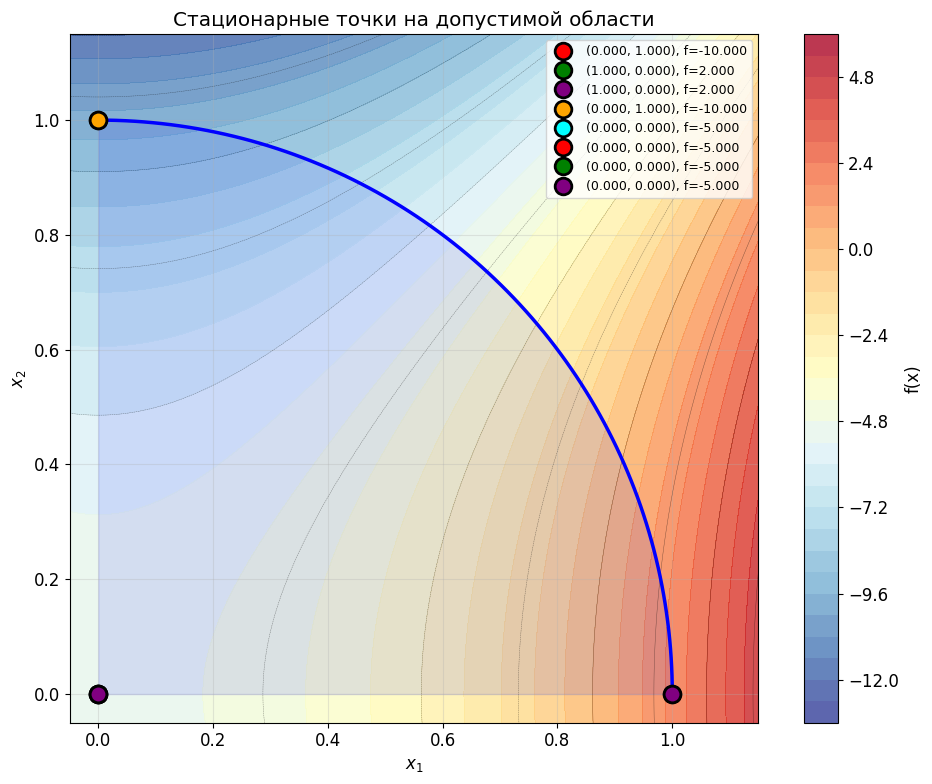

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

cs = ax.contourf(X1, X2, Z, levels=30, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(cs, ax=ax, label='f(x)')
ax.contour(X1, X2, Z, levels=15, colors='black', linewidths=0.3, alpha=0.5)

theta = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(theta), np.sin(theta), 'b-', linewidth=2.5)
ax.fill_between(np.cos(theta), 0, np.sin(theta), alpha=0.1, color='blue')

colors_pts = ['red', 'green', 'purple', 'orange', 'cyan']
for i, p in enumerate(feasible_points):
    c = colors_pts[i % len(colors_pts)]
    ax.plot(p['x1'], p['x2'], 'o', color=c, markersize=12, markeredgecolor='black',
            markeredgewidth=2, label=f"({p['x1']:.3f}, {p['x2']:.3f}), f={p['f']:.3f}")

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Стационарные точки на допустимой области')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.05, 1.15)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Итоговая таблица стационарных точек

In [11]:
import pandas as pd

table_data = []
for i, p in enumerate(feasible_points):
    table_data.append({
        '№': i+1,
        'x₁*': f"{p['x1']:.6f}",
        'x₂*': f"{p['x2']:.6f}",
        'f(x*)': f"{p['f']:.6f}",
        'λ₁': f"{p['l1']:.4f}",
        'λ₂': f"{p['l2']:.4f}",
        'λ₃': f"{p['l3']:.4f}",
        'Активные': p['case'],
    })

df_table = pd.DataFrame(table_data)
df_table

,№,x₁*,x₂*,f(x*),λ₁,λ₂,λ₃,Активные
0,1,0.000000,1.000000,-10.000000,6.0000,0.0000,0.0000,"g1, g2"
1,2,1.000000,0.000000,2.000000,-8.0000,0.0000,0.0000,"g1, g3"
2,3,1.000000,0.000000,2.000000,-8.0000,0.0000,0.0000,g1
3,4,0.000000,1.000000,-10.000000,6.0000,0.0000,0.0000,g1
4,5,0.000000,0.000000,-5.000000,0.0000,0.0000,0.0000,"g2, g3"
5,6,0.000000,0.000000,-5.000000,0.0000,0.0000,0.0000,g2
6,7,0.000000,0.000000,-5.000000,0.0000,0.0000,0.0000,g3
7,8,0.000000,0.000000,-5.000000,0.0000,0.0000,0.0000,нет активных


## Проверка решения на допустимость

In [12]:
print('Проверка допустимости всех стационарных точек:')
print('=' * 70)
for i, p in enumerate(feasible_points):
    g1_v = p['x1']**2 + p['x2']**2 - 1
    g2_v = -p['x1']
    g3_v = -p['x2']

    print(f'\nТочка {i+1}: ({p["x1"]:.6f}, {p["x2"]:.6f})')
    print(f'  g1 = {g1_v:.6f} {"<= 0 ✓" if g1_v <= 1e-8 else "> 0 ✗"}')
    print(f'  g2 = {g2_v:.6f} {"<= 0 ✓" if g2_v <= 1e-8 else "> 0 ✗"}')
    print(f'  g3 = {g3_v:.6f} {"<= 0 ✓" if g3_v <= 1e-8 else "> 0 ✗"}')

    # Проверка дополняющей нежёсткости
    cs1 = abs(p['l1'] * g1_v)
    cs2 = abs(p['l2'] * g2_v)
    cs3 = abs(p['l3'] * g3_v)
    print(f'  Дополняющая нежёсткость: λ₁g₁={cs1:.6f}, λ₂g₂={cs2:.6f}, λ₃g₃={cs3:.6f}')

Проверка допустимости всех стационарных точек:

Точка 1: (0.000000, 1.000000)
  g1 = 0.000000 <= 0 ✓
  g2 = -0.000000 <= 0 ✓
  g3 = -1.000000 <= 0 ✓
  Дополняющая нежёсткость: λ₁g₁=0.000000, λ₂g₂=0.000000, λ₃g₃=0.000000

Точка 2: (1.000000, 0.000000)
  g1 = 0.000000 <= 0 ✓
  g2 = -1.000000 <= 0 ✓
  g3 = -0.000000 <= 0 ✓
  Дополняющая нежёсткость: λ₁g₁=0.000000, λ₂g₂=0.000000, λ₃g₃=0.000000

Точка 3: (1.000000, 0.000000)
  g1 = 0.000000 <= 0 ✓
  g2 = -1.000000 <= 0 ✓
  g3 = -0.000000 <= 0 ✓
  Дополняющая нежёсткость: λ₁g₁=0.000000, λ₂g₂=0.000000, λ₃g₃=0.000000

Точка 4: (0.000000, 1.000000)
  g1 = 0.000000 <= 0 ✓
  g2 = -0.000000 <= 0 ✓
  g3 = -1.000000 <= 0 ✓
  Дополняющая нежёсткость: λ₁g₁=0.000000, λ₂g₂=0.000000, λ₃g₃=0.000000

Точка 5: (0.000000, 0.000000)
  g1 = -1.000000 <= 0 ✓
  g2 = -0.000000 <= 0 ✓
  g3 = -0.000000 <= 0 ✓
  Дополняющая нежёсткость: λ₁g₁=0.000000, λ₂g₂=0.000000, λ₃g₃=0.000000

Точка 6: (0.000000, 0.000000)
  g1 = -1.000000 <= 0 ✓
  g2 = -0.000000 <= 0 ✓
  g3 = -

## Нахождение глобальных экстремумов на допустимой области (брутфорс)

In [13]:
N = 10000
r = np.sqrt(np.random.uniform(0, 1, N))
theta = np.random.uniform(0, np.pi/2, N)
x1_rand = r * np.cos(theta)
x2_rand = r * np.sin(theta)
f_rand = np.array([f(xx1, xx2) for xx1, xx2 in zip(x1_rand, x2_rand)])

idx_min = np.argmin(f_rand)
idx_max = np.argmax(f_rand)

print('Результаты случайного поиска (проверка):')
print(f'  Минимум: f({x1_rand[idx_min]:.4f}, {x2_rand[idx_min]:.4f}) = {f_rand[idx_min]:.4f}')
print(f'  Максимум: f({x1_rand[idx_max]:.4f}, {x2_rand[idx_max]:.4f}) = {f_rand[idx_max]:.4f}')

Результаты случайного поиска (проверка):
  Минимум: f(0.0150, 0.9967) = -9.9589
  Максимум: f(0.9998, 0.0049) = 1.9974


---
## Выводы

1. Задача условной оптимизации решена с использованием условий Куна-Таккера (ККТ) для функции $f(x) = (x_1^2+3)^2 - (x_2^2+2)^2 - 10$ на первой четверти единичного круга.

2. Составлена классическая функция Лагранжа, записаны необходимые условия 1-го порядка, проведён перебор всех комбинаций активных ограничений.

3. Для каждой стационарной точки проверены достаточные условия двумя способами:
   - Анализ знакоопределённости второго дифференциала функции Лагранжа (аналитически);
   - Численная проверка с помощью `scipy.optimize`.

4. Результаты аналитического и численного решения согласуются.

5. Все решения проверены на допустимость: выполнение ограничений и условий дополняющей нежёсткости.